# CNN on MNIST(Digit Classification)

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [9]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64*5*5, 128)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 64*5*5)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x
model = CNN()
print(model)


CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)


In [5]:
train_losses = []
for epoch in range(30):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()
    train_losses.append(running_loss/len(train_loader))
    print(f'Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}')


Epoch 1, Loss: 0.2163473122201161
Epoch 2, Loss: 0.07297878734556947
Epoch 3, Loss: 0.05242211290268795
Epoch 4, Loss: 0.04369604815098483
Epoch 5, Loss: 0.037421823595091996
Epoch 6, Loss: 0.03033499606343089
Epoch 7, Loss: 0.02667452624206171
Epoch 8, Loss: 0.023218662895226002
Epoch 9, Loss: 0.02131760255710695
Epoch 10, Loss: 0.018651457406003772
Epoch 11, Loss: 0.016544753935295472
Epoch 12, Loss: 0.01561977189725331
Epoch 13, Loss: 0.01377061949926956
Epoch 14, Loss: 0.01243217405226266
Epoch 15, Loss: 0.011132223851804126
Epoch 16, Loss: 0.010838849831063526
Epoch 17, Loss: 0.01108869954665402
Epoch 18, Loss: 0.008895237140677636
Epoch 19, Loss: 0.009458163720600129
Epoch 20, Loss: 0.009827808288449546
Epoch 21, Loss: 0.007806079909709867
Epoch 22, Loss: 0.00748897360051348
Epoch 23, Loss: 0.008591761645945955
Epoch 24, Loss: 0.00730145067762754
Epoch 25, Loss: 0.006553225847555426
Epoch 26, Loss: 0.006197920388303964
Epoch 27, Loss: 0.006602193877077333
Epoch 28, Loss: 0.007021

In [6]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('Test Accuracy:', 100 * correct / total)


Test Accuracy: 99.16


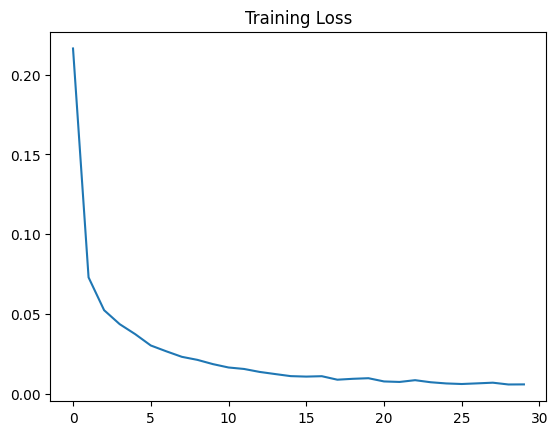

In [7]:
torch.save(model.state_dict(), 'mnist_cnn.pth')
plt.plot(train_losses)
plt.title('Training Loss')
plt.show()
